# Import libraries and Cucumber Scoring model 

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import torch
from torch.autograd import Function
import torchvision
from torchvision import models
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F

from captum.attr import IntegratedGradients
from captum.attr import NoiseTunnel
from captum.attr import GradientShap
from captum.attr import DeepLift
from captum.attr import Occlusion 
from captum.attr import GuidedGradCam

from captum.attr import visualization as viz

from src.dataset.dataset import CucuLeafDataset
from src.models.train import CucumberScoringSystem

In [2]:
system = CucumberScoringSystem.load_from_checkpoint('checkpoints/cp_epoch=21_val_loss=0.0021_val_R2=0.932.ckpt')
model = system.model

In [3]:
for layer, values in model.named_parameters():
    print(layer)

encoder.layer0.conv1.weight
encoder.layer0.bn1.weight
encoder.layer0.bn1.bias
encoder.layer1.0.conv1.weight
encoder.layer1.0.bn1.weight
encoder.layer1.0.bn1.bias
encoder.layer1.0.conv2.weight
encoder.layer1.0.bn2.weight
encoder.layer1.0.bn2.bias
encoder.layer1.0.conv3.weight
encoder.layer1.0.bn3.weight
encoder.layer1.0.bn3.bias
encoder.layer1.0.se_module.fc1.weight
encoder.layer1.0.se_module.fc1.bias
encoder.layer1.0.se_module.fc2.weight
encoder.layer1.0.se_module.fc2.bias
encoder.layer1.0.downsample.0.weight
encoder.layer1.0.downsample.1.weight
encoder.layer1.0.downsample.1.bias
encoder.layer1.1.conv1.weight
encoder.layer1.1.bn1.weight
encoder.layer1.1.bn1.bias
encoder.layer1.1.conv2.weight
encoder.layer1.1.bn2.weight
encoder.layer1.1.bn2.bias
encoder.layer1.1.conv3.weight
encoder.layer1.1.bn3.weight
encoder.layer1.1.bn3.bias
encoder.layer1.1.se_module.fc1.weight
encoder.layer1.1.se_module.fc1.bias
encoder.layer1.1.se_module.fc2.weight
encoder.layer1.1.se_module.fc2.bias
encoder.layer

# Load a test image and <br>transform the input image format to tensor

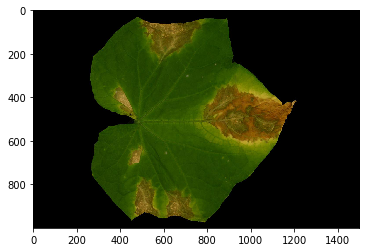

In [4]:
greenhouse_path = 'data/source_leaf/non_phenobox_images/Pilot picture/'
img_path = 'data/images_leaf/'

img_file = 'Row_4_part2_Mycos18_002_mycos_01.jpg'
img = Image.open(img_path + img_file)

plt.imshow(img)

In [5]:
transform = transforms.Compose([
                                 transforms.Resize([224,224]),
                                 transforms.ToTensor()   # converts the image to a tensor with values between 0 and 1
                                ])


# normalize to follow 0-centered imagenet pixel rgb distribution
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

In [6]:
transformed_img = transform(img)
transformed_img.shape

torch.Size([3, 224, 224])

In [7]:
norm_img = normalize(transformed_img)
input_img = norm_img.unsqueeze(0)
input_img.shape

torch.Size([1, 3, 224, 224])

In [8]:
output = model(input_img)
print(output[0][0])

tensor(0.2473, grad_fn=<SelectBackward>)


In [9]:
label_file = '/data/scores_leaf.csv'
label = pd.read_csv(os.getcwd() + label_file)
label

,name,score
0,Row_3_7Mycos18_003_mycos_01.jpg,2.333333
1,Row_3_7_mycos_01.jpg,2.666667
2,Row_3_Mycos18_001_mycos_01.jpg,2.333333
3,Row_3_Mycos18_001_mycos_02.jpg,2.666667
4,Row_3_Mycos18_001_mycos_03.jpg,2.333333
...,...,...
1011,Final_2_22_1_3_109.jpg,4.000000
1012,Final_2_22_2_2_110.jpg,4.500000
1013,Final_2_22_3_11_111.jpg,2.000000
1014,Final_2_22_4_4_112.jpg,3.500000


In [10]:
prediction_score = output
label_score = label.loc[label['name'] == img_file]['score'].item()
label_score

6.0

# Captum 
##  Intergrated Gradients

In [13]:
ig = IntegratedGradients(model)
attr_ig = ig.attribute(input_img,
                       baselines = input_img * 0,
                       n_steps=200)

In [15]:
default_cmap = LinearSegmentedColormap.from_list('custom blue', 
                                                 [(0, '#ffffff'),
                                                  (0.25, '#000000'),
                                                  (1, '#000000')], N=256)

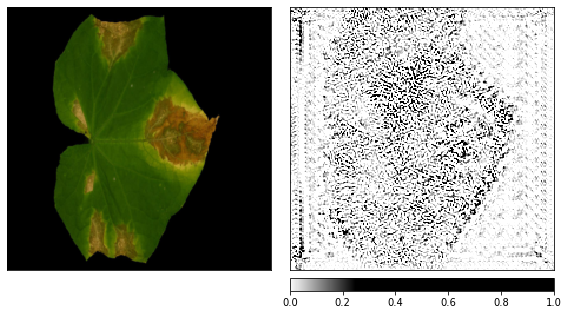

In [38]:
# visualizing the image and corresponding attributions 
# by overlaying the latter on the image.

_ = viz.visualize_image_attr_multiple(np.transpose(attr_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True)

positive attribution indicates that the presence of the area increases the prediction score <Br>

negative attribution indicates distractor areas whose absence increases the score

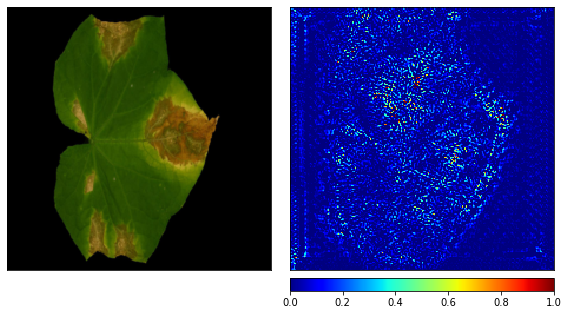

In [45]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "negative"],
                                      cmap='jet',
                                      show_colorbar=True)

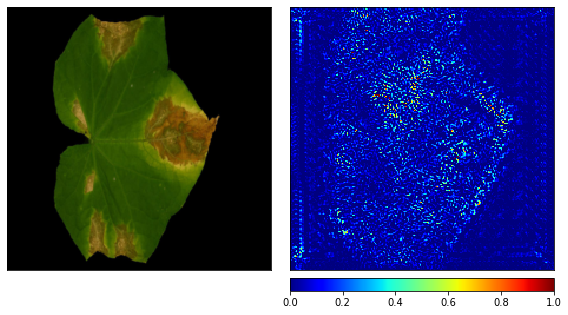

In [47]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "positive"],
                                      cmap='jet',
                                      show_colorbar=True)

## Gradient SHAP

GradientShap approximates SHAP values by computing the expectations of gradients by randomly sampling from the distribution of baselines/references. 

It adds white noise to each input sample 'n_samples times', selects a random baseline from baselines’ distribution and a random point along the path between the baseline and the input, and computes the gradient of outputs with respect to those selected random points. 

The final SHAP values represent the expected values of gradients * (inputs - baselines).

GradientShap makes an assumption that the input features are independent and that the explanation model is linear, meaning that the explanations are modeled through the additive composition of feature effects.
Under those assumptions, SHAP value can be approximated as the expectation of gradients that are computed for randomly generated `n_samples` input samples after adding gaussian noise `n_samples` times to each input for different baselines/references.


Source: https://captum.ai/api/gradient_shap.html,

A linear explanation model which uses a distribution of reference samples (in this case two images) to explain predictions of the model. 

It computes the expectation of gradients for an input which was chosen randomly between the input and a baseline. The baseline is also chosen randomly from given baseline distribution.

In [11]:
gradient_shap = GradientShap(model)

# Defining baseline distribution of images
rand_img_dist = torch.cat([input_img * 0, input_img * 1])

attr_gs = gradient_shap.attribute(input_img,
                                  n_samples=50,
                                  stdevs=0.0001,
                                  baselines=rand_img_dist)

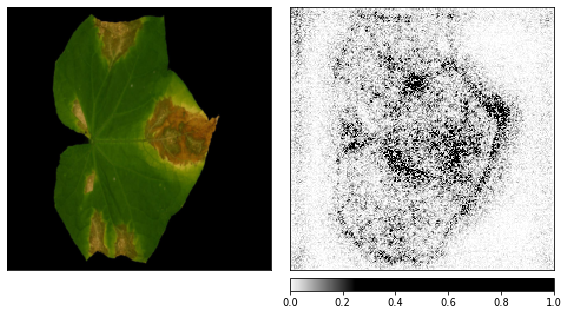

In [73]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_gs.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True)

## Noise Tunnel + gradient SHAP

Noise Tunnel adds gaussian noise to each input in the batch n_samples times and applies the given attribution algorithm to each of the samples. 

The attributions of the samples are combined based on the given noise tunnel type (nt_type): 

1) If nt_type is smoothgrad, the mean of the sampled attributions is returnedThis approximates smoothing the given attribution method with a Gaussian Kernel.

2) If nt_type is smoothgrad_sq, the mean of the squared sample attributions is returned. 
 
3) If nt_type is vargrad, the variance of the sample attributions is returned.

In [13]:
noise_tunnel = NoiseTunnel(gradient_shap)

attr_shap_nt = noise_tunnel.attribute(input_img, 
                                    n_samples=10, 
                                    baselines=0*input_img,
                                    nt_type='smoothgrad_sq')

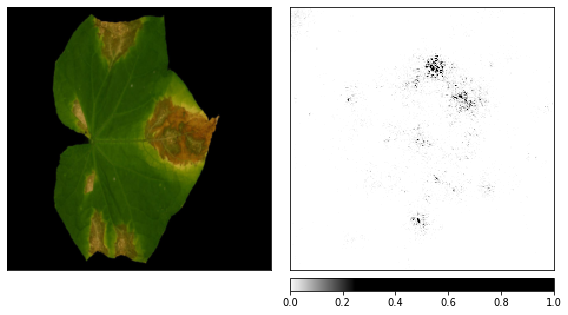

In [16]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_shap_nt.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True)

# Occulsion based attribution

We can estimate which areas of the image are critical for the regressioner/classifier's decision by occluding them and quantifying how the decision changes.



In [74]:
occlusion = Occlusion(model)
attr_oc = occlusion.attribute(input_img, 
                              strides = (3, 9, 9), # smaller = more fine-grained attribution but slower
                              sliding_window_shapes = (3, 15, 15), # choose size enough to change object appearance
                              baselines = 0 ) # values to occlude the image with. 0 corresponds to gray

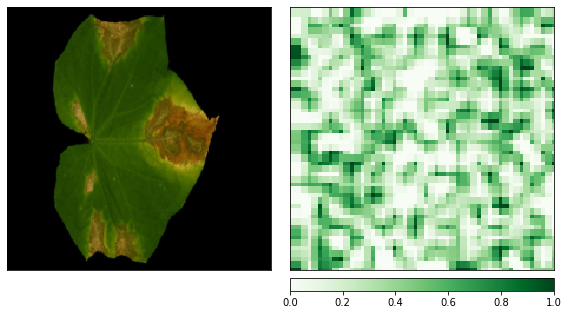

In [75]:
# Let us visualize the attribution, focusing on the areas 
# with positive attribution (those that are critical for the 
# regressioner's/classifier's decision):

_ = viz.visualize_image_attr_multiple(np.transpose(attr_oc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map"], 
                                      ["all", "positive"], 
                                      show_colorbar = True,
                                      outlier_perc=2
                                     )

# Grad Cam

Source Code: https://github.com/kazuto1011/grad-cam-pytorch

GradCAM attributions are computed with respect to the layer provided in the constructor, and attributions are upsampled to match the input size. GradCAM is designed for convolutional neural networks, and is usually applied to the last convolutional layer.
<bc>
1. Wrap your model with visualization classes defined in grad_cam.py
2. Run forward() with images
3. Run backward() with a list of specific classes
4. Run generate() to export results

In [55]:
model.freeze()
input_img.requires_grad = True

In [56]:
import gradcam2 

gr = gradcam2.GradCAM(model) #1
probs, ids = gr.forward(input_img) #2
probs, ids

(tensor([[1.]], grad_fn=<SortBackward>), tensor([[0]]))

In [57]:
gr.backward(ids=torch.tensor([[0]])) #3
regions = gr.generate(target_layer='encoder.layer0') #4

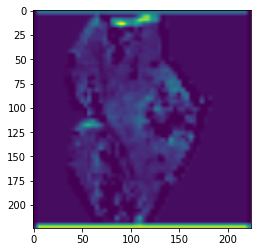

In [58]:
plt.imshow(regions[0][0]) 

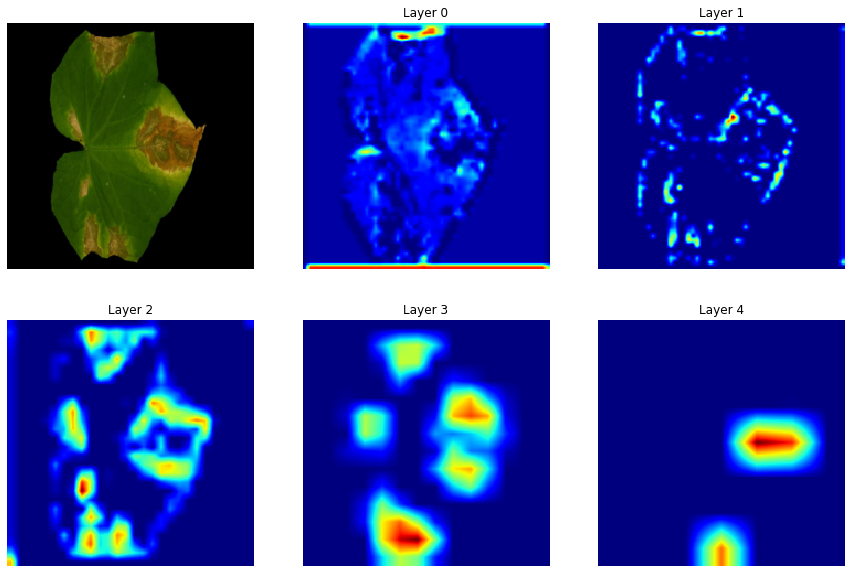

In [66]:
fig, axs = plt.subplots(2, 3, figsize=(15,10), squeeze=False)
ind = 0
for i in range(2):
    for j in range(3):
        if (i == 0) & (j==0):
            axs[0][0].imshow(transformed_img.permute(1,2,0))
            axs[0][0].axis('off')
        else:
            regions = gr.generate(target_layer='encoder.layer'+str(ind))
            axs[i][j].imshow(regions[0][0], cmap='jet')
            axs[i][j].axis('off')
            axs[i][j].set_title('Layer '+str(ind))
            ind += 1
